# Analyse SAE 2.04 | Partie Mathématiques

Dans le cadre de la SAE 2.04, la deuxième partie consiste à analyser des données issues de deux fichiers CSV représentant les absences d'une promotion de BUT Informatique à Laval.

Cette analyse s'articule autour de plusieurs axes :
- calcul d'indicateurs statistiques
- création de nouvelles variables
- visualisation des résultats

Contraintes imposées :
- traiter chaque type de variable selon les méthodes étudiées en cours
- faire preuve de créativité dans le choix des variables à inventer et à étudier

---

Les deux fichiers CSV sont constitués des colonnes suivantes :

**CSV 1 — Données étudiants**

| Colonne        | Description                                                                                                        |Type        |
|----------------|--------------------------------------------------------------------------------------------------------------------|------------|
| `code_etu`     | Identifiant unique de l'étudiant (fictif)                                                                          |            |
| `nom`          | Nom de l'étudiant (anonymisé)                                                                                      |            |
| `prenom`       | Prénom de l'étudiant (anonymisé)                                                                                   |            |
| `clt_parcsup`  | Classement Parcoursup lors du recrutement — attention, les classements bac général et bac techno sont indépendants |continue    |
| `bac`          | Type de bac obtenu                                                                                                 |nominale    |
| `ue_i_j`       | Note obtenue à l'UE j du semestre i                                                                                |continue    |
| `res_but_1`    | Résultat à l'issue de la 1ère année de BUT                                                                         |ordinale    |
| `res_but_2`    | Résultat à l'issue de la 2ème année de BUT                                                                         |ordinale    |
| `res_but_3`    | Résultat à l'issue de la 3ème année de BUT                                                                         |ordinale    |
| `avis_pe`      | Avis de poursuite d'études                                                                                         |ordinale    |
| `app_but_2`    | Apprentissage en BUT 2                                                                                             |nominale    |
| `app_but_3`    | Apprentissage en BUT 3                                                                                             |nominale    |
| `but_3_etr`    | Année de BUT 3 effectuée à l'étranger                                                                              |nominale    |

**CSV 2 — Données absences**

| Colonne         | Description                                                                                         |Type          |
|-----------------|-----------------------------------------------------------------------------------------------------|--------------|
| `date`          | Date et heure de début de la séance concernée (format datetime)                                     |              |
| `code_etu`      | Identifiant unique de l'étudiant                                                                    |              |
| `nature`        | Nature de l'absence : `absence` ou `retard`                                                         |nominale      |
| `duree_retard`  | Durée du retard, renseignée uniquement si `nature == "retard"`                                      |discret       |
| `justifiee`     | Indique si l'absence est justifiée                                                                  |nominale      |
| `excusee`       | Indique si l'absence est excusée                                                                    |nominale      |
| `enseignant`    | Nom de l'enseignant concerné                                                                        |nominale      |
| `cours`         | Intitulé du cours concerné                                                                          |nominale      |
| `type`          | Type de cours concerné                                                                              |nominale      |
| `duree_cours`   | Durée du cours concerné (minutes)                                                                   |discret       |

---

## Sommaire

1. [Cours sur l'analyse des données](#1-cours-sur-lanalyse-des-données)
   - 1.1 [Variables univariées qualitatives](#11-variables-univariées-qualitatives)
      - 1.1.1 [Nominales](#111-nominales)
      - 1.1.2 [Ordinales](#112-ordinales)
   - 1.2 [Variables univariées quantitatives](#12-variables-univariées-quantitatives)
      - 1.2.1 [Discrètes](#121-discrètes)
      - 1.2.2 [Continues](#122-continues)
   - 1.3 [Variables bivariées](#13-variables-bivariées)
      - 1.3.1 [Quantitative — Quantitative](#131-quantitative--quantitative)
      - 1.3.2 [Quantitative — Qualitative](#132-quantitative--qualitative)
      - 1.3.3 [Qualitative — Qualitative](#133-qualitative--qualitative)
2. [Choix des analyses et variables créées](#2-choix-des-analyses-et-variables-créées)
3. [Préparation des données](#3-préparation-des-données)
   - 3.1 [Chargement des fichiers CSV](#31-chargement-des-fichiers-csv)
   - 3.2 [Nettoyage et traitement](#32-nettoyage-et-traitement)
4. [Analyse statistique](#4-analyse-statistique)
   - 4.1 [Étude des moyennes par UE (`ue_i_j`)](#41-étude-des-moyennes-par-ue)
   - 4.2 [Répartition des absences et des retards (`nature`)](#42-répartition-des-absences-et-des-retards)
   - 4.3 [Analyse de l'assiduité par type de cours (`type`)](#43-analyse-de-lassiduité-par-type-de-cours)
   - 4.4 [Évolution des taux de réussite annuelle (`res_but_1` / `2` / `3`)](#45-évolution-des-taux-de-réussite-annuelle)
   - 4.5 [Analyse de la durée et des extrapolations des retards (`duree_retard`)](#46-analyse-de-la-durée-des-retards)
   - 4.6 [Statistiques des signalements par enseignant (`enseignant`)](#47-statistiques-des-signalements-par-enseignant)
   - 4.7 [Influence du volume d'absences sur la moyenne (`nb_abs_ret` $\times$ `avg_note_per_year`)](#48-influence-du-volume-dabsences-sur-la-moyenne)
   - 4.8 [Comparaison de la réussite selon la filière de bac (`avg_note` $\times$ `type_bac`)](#49-comparaison-de-la-réussite-selon-le-bac)
   - 4.9 [Tendance à l'absentéisme par type de bac (`type_bac` $\times$ `nb_abs_ret`)](#410-tendance-à-labsentéisme-par-type-de-bac)
   - 4.10 [Appétence pour la mobilité internationale selon le bac (`but_3_etr` $\times$ `type_bac`)](#411-mobilité-internationale-selon-le-bac)
   - 4.11 [Orientation vers l'apprentissage selon le bac (`alternance` $\times$ `type_bac`)](#412-orientation-vers-lapprentissage-selon-le-bac)
   - 4.12 [Impact du statut d'alternant sur les performances (`alternance` $\times$ `avg_note`)](#413-impact-du-statut-dalternant-sur-les-performances)
   - 4.13 [Fiabilité des données d'assiduité des alternants (`alternance` $\times$ `nb_abs_ret`)](#414-fiabilité-des-données-des-alternants)
   - 4.14 [Influence du classement d'entrée sur l'avis des professeurs (`clt_parcsup` $\times$ `avis_pe`)](#415-influence-du-classement-sur-lavis-enseignant)
   - 4.15 [Corrélation entre excellence des notes et avis de poursuite (`avis_pe` $\times$ `avg_note_per_year`)](#416-corrélation-entre-notes-et-avis-de-poursuite)
   - 4.16 [Lien entre le classement Parcoursup et les notes obtenues (`avg_note` $\times$ `clt_parcsup`)](#417-lien-entre-classement-parcoursup-et-notes)
5. [Conclusion](#5-conclusion)
---

## Cours sur l'analyse des données

### Variables univariées qualitatives

#### Variables univariées qualitatives nominales

Une variable qualitative nominale prend des modalités comme valeurs, sans ordre logique entre elles.

Les outils d'analyse :

- **Tableau de distribution** (effectifs et fréquences) : permet de visualiser la répartition dans chaque modalité
- **Mode** : indique la modalité la plus fréquente
- **Représentation graphique** : diagramme en barres, circulaire ou en bâtons pour une lecture plus visuelle de la répartition

---

#### Variables univariées qualitatives ordinales

Une variable qualitative ordinale prend des modalités comme valeurs, avec un ordre logique entre elles.

Les outils d'analyse :

- **Tableau de distribution** (effectifs et fréquences) : permet de visualiser la répartition dans chaque modalité
- **Mode** : indique la modalité la plus fréquente
- **Médiane ordinale** : indique la modalité centrale en tenant compte de l'ordre
- **Représentation graphique** : diagramme en barres ou en bâtons, en respectant l'ordre des modalités

---

### Variables univariées quantitatives

#### Variables univariées quantitatives discrètes

Une variable quantitative discrète prend des valeurs numériques isolées (entières ou dénombrables).

Les outils d'analyse :

- **Tableau de distribution** (effectifs et fréquences) : permet de visualiser la répartition des valeurs
- **Représentation graphique** : diagramme en bâtons (en respectant l'échelle), courbe des fréquences cumulées
- **Résumés de position** : moyenne et médiane, permettant de caractériser un individu type
- **Résumés de dispersion** : variance et écart-type, indiquant l'étendue des écarts autour de la moyenne
- **Boîte à moustaches** : synthèse visuelle des extremums, quartiles et médiane

---

#### Variables univariées quantitatives continues

Une variable quantitative continue prend ses valeurs dans des intervalles.

Les outils d'analyse :

- **Tableau de distribution** (effectifs, fréquences ou densités) : permet de visualiser la répartition par classe
- **Représentation graphique** : histogramme des densités, courbe des fréquences cumulées
- **Résumés de position** : moyenne pour l'individu type, médiane pour limiter l'effet des valeurs extrêmes
- **Résumés de dispersion** : variance, écart-type et quartiles permettant de détecter les valeurs aberrantes

---

### Variables bivariées

#### Variables bivariées quantitative - quantitative

Pour analyser la relation entre deux variables quantitatives :

- **Nuage de points** : représentation graphique de la distribution jointe des deux variables
- **Covariance** : mesure le sens de la relation linéaire entre les deux variables
- **Coefficient de corrélation de Pearson** : mesure l'intensité et le sens de la liaison linéaire, compris entre -1 et 1
- **Droite de régression linéaire** : modélise la relation entre les deux variables et permet de faire des prédictions

---

#### Variables bivariées quantitative - qualitative

Pour analyser la relation entre une variable quantitative et une variable qualitative :

- **Tableau des moyennes par modalité** : compare la moyenne de la variable quantitative pour chaque groupe
- **Boîtes à moustaches par groupe** : visualise et compare la distribution de la variable quantitative selon les modalités
- **Rapport de corrélation η²** : mesure la part de variance de la variable quantitative expliquée par la variable qualitative

---

#### Variables bivariées qualitative - qualitative

Pour analyser la relation entre deux variables qualitatives :

- **Tableau de contingence** : représente la distribution jointe des effectifs selon les deux variables
- **Distributions marginales** : permettent d'analyser la distribution de chaque variable indépendamment
- **Distributions conditionnelles** : permettent d'analyser la distribution d'une variable selon les modalités de l'autre
- **Test du Chi²** : mesure si les deux variables sont indépendantes ou liées

### 1. Tableau des Variables Construites

Ce tableau présente les nouvelles variables générées et calculées à partir des données brutes pour enrichir l'analyse.

| Nom de la variable | Source / Mode de calcul | Description / Objectif | Type |
| :--- | :--- | :--- | :--- |
| **`nb_ret`** | Compte des lignes par étudiant dans les fichiers d'absences | Nombre total d'absences accumulés par un élève. | Quantitative discrète |
| **`nb_abs`** | Compte des lignes par étudiant des retards | Nombre total de retards accumulés par un élève. | Quantitative discrète |
| **`avg_ue_i_per_year`** | Moyenne des colonnes `ue_i_j` regroupées par année | Moyenne obtenue pour une UE spécifique par élève et par année. | Quantitative continue |
| **`avg_note_per_year`** | Moyenne de l'ensemble des UE d'une même année | Moyenne générale annuelle calculée pour chaque élève. | Quantitative continue |
| **`avg_note`** | Calculée à partir des `avg_note_per_year` | Moyenne générale globale de l'étudiant sur l'ensemble de son cursus. | Quantitative continue |
| **`alternance`** | Basée sur `app_but_2` ou `app_but_3` | Variable binaire indiquant si l'élève est apprenti/alternant au cours de son BUT. | Qualitative nominale |
| **`est_defaillant`** | Algorithme basé sur l'INE, les dates et la durée des absences | Détermine si un élève est déclaré défaillant selon son nombre de demi-journées d'absences injustifiées. | Qualitative nominale |

---

### 2. Tableau des Analyses et Croisements d'Étude

Ce tableau synthétise les axes d'analyse (univariés et bivariés) permettant de répondre aux problématiques de la SAE.

| Variables étudiées | Problématique / Objectif de l'analyse |
| :--- | :--- |
| **`ue_i_j`** | Analyser les moyennes de chaque UE pour identifier d'éventuels écarts de notation ou difficultés majeures. |
| **`nature`** | Déterminer s'il y a globalement une majorité d'absences ou de retards. |
| **`type`** | Identifier la modalité de cours (CM, TD, TP) qui comptabilise le plus de manquements. |
| **`res_but_1` / `2` / `3`** | Analyser les taux de réussite, d'admission et de passage d'une année à l'autre. |
| **`duree_retard`** | Calculer la durée moyenne d'un retard et repérer les valeurs aberrantes. |
| **`enseignant`** | Identifier quel enseignant déclare ou fait face au plus grand nombre d'absences/retards. |
| **(`nb_abs` + `nb_ret`) $\times$ `avg_note_per_year`** | Mesurer si le volume d'absences et de retards influence négativement la moyenne de l'élève. |
| **`avg_note` $\times$ `type_bac`** | Déterminer quelle filière de baccalauréat obtient le meilleur taux de réussite académique. |
| **`type_bac` $\times$ `nb_abs_ret`** | Observer si le profil du bac d'origine est lié à une tendance à l'absentéisme. |
| **`but_3_etr` $\times$ `type_bac`** | Identifier quel type de bac s'oriente le plus vers une mobilité internationale en BUT 3. |
| **`alternance` $\times$ `type_bac`** | Analyser s'il y a un type de bac qui privilégie ou accède le plus à la voie de l'apprentissage. |
| **`alternance` $\times$ `avg_note`** | Étudier si le statut d'alternant impacte positivement ou négativement l'investissement et les notes scolaires. |
| **`alternance` $\times$ `nb_abs_ret`** | Vérifier la fiabilité et la cohérence des données d'assiduité spécifiques aux alternants. |
| **`clt_parcsup` $\times$ `avis_pe`** | Analyser si le classement initial sur Parcoursup a une influence sur l'avis final de poursuite d'études. |
| **`avis_pe` $\times$ `avg_note_per_year`** | Vérifier si l'avis de poursuite d'études est directement corrélé à l'excellence des notes obtenues. |
| **`avg_note` $\times$ `clt_parcsup`** | Évaluer l'efficacité de Parcoursup : les étudiants les mieux classés à l'entrée sont-ils ceux qui ont les meilleures moyennes ? |

# Préparation des données
  ## Chargement des fichiers CSV


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from typing import *
from pandas import Series
from IPython.display import display, Markdown

In [3]:
df_resultats = pd.read_csv('./data/resultats.csv', sep=',', decimal=',');

# Dataframe pour chaque année :

df_abs_1 = pd.read_csv('./data/absences_1.csv', sep=';', decimal=',');
df_abs_2 = pd.read_csv('./data/absences_2.csv', sep=';', decimal=',');
df_abs_3 = pd.read_csv('./data/absences_3.csv', sep=';', decimal=',');

# Dataframe pour la formation : 

df_abs_total = pd.concat([df_abs_1, df_abs_2, df_abs_3], ignore_index=True)

df_resultats.head()

,code_etu,nom,prenom,clt_parcsup,bac,ue_1_1,ue_2_1,ue_3_1,ue_4_1,ue_5_1,...,ue_4_6,ue_5_6,ue_6_6,res_but_1,res_but_2,res_but_3,avis_pe,app_but_2,app_but_3,but_3_etr
0,1,Guilmette,Sébastien,137.0,S-Sciences,14.16,13.61,NaN,NaN,NaN,...,NaN,NaN,NaN,ADM,TSF,NaN,NaN,NaN,NaN,NaN
1,2,Villeneuve,Eustache,NaN,STI2D,14.95,12.61,11.58,NaN,NaN,...,NaN,NaN,NaN,ADM,AJNAR,NaN,NaN,non,NaN,NaN
2,3,Ducharme,Aurélie,133.0,STI2D,10.80,11.95,11.55,12.74,14.07,...,11.91,14.03,14.03,ADM,ADM,ADM,N,non,oui,NaN
3,4,Miron,Carole,14.0,STI2D,17.42,16.49,15.81,16.52,16.81,...,16.36,16.31,16.31,ADM,ADM,ADM,TF,oui,oui,NaN
4,5,Mailly,Fabien,113.0,NBGE,14.04,14.25,12.71,15.00,14.95,...,15.65,14.03,14.03,ADM,ADM,ADM,F,non,oui,NaN


In [4]:
df_abs_1.head()

,date,code_etu,nature,duree_retard,justifiee,excusee,enseignant,cours,type,duree_cours
0,2021-09-02T14:00:00,27,absence,NaN,False,True,Nathalie VIEILLARD,R1.08 Introdution à la Gestion des organisations,TD,90
1,2021-09-02T15:30:00,27,absence,NaN,False,True,Yann WALKOWIAK,R1.07 Outils mathématiques fondamentaux,TD,90
2,2021-09-05T11:20:00,38,absence,NaN,True,False,Charles DECELLIERES,R1.02 Développement d'interfaces web,CM,60
3,2021-09-05T13:30:00,38,absence,NaN,True,False,Lahcen OUBAHSSI,R1.04 Intro aux syst. d'exploitation & à leur ...,TD,90
4,2021-09-05T15:00:00,38,absence,NaN,True,False,Charles DECELLIERES,R1.02 Développement d'interfaces web,TD,180


In [5]:
df_abs_2.head()


,date,code_etu,nature,duree_retard,justifiee,excusee,enseignant,cours,type,duree_cours
0,2022-09-06T08:30:00,31,absence,NaN,True,False,Pierre LAFORCADE,R3.04 Qualité et Développement,TD,180
1,2022-09-07T13:30:00,31,absence,NaN,False,True,Bruno ERNET,R3.05 Programmation système,TP,180
2,2022-09-07T16:30:00,31,absence,NaN,False,True,Nathalie VIEILLARD,R3.13 Communication professionnelle,TD,90
3,2022-09-08T09:00:00,23,absence,NaN,True,False,Charles DECELLIERES,R3.01 Développement web,TD,180
4,2022-09-09T09:00:00,14,absence,NaN,False,True,Charles DECELLIERES,R3.01 Développement web,TD,180


In [6]:
df_abs_3.head()

,date,code_etu,nature,duree_retard,justifiee,excusee,enseignant,cours,type,duree_cours
0,2023-09-07T15:00:00,13,absence,NaN,True,False,Hélène CROZET,R5.Real.14 Anglais,TD,90
1,2023-09-11T11:20:00,43,absence,NaN,False,False,Ludovic HAMON,Présentation Stage,PRESENTATION STAGE,60
2,2023-10-02T09:00:00,52,absence,NaN,True,False,Nadege RIBOT,R5.01Initiation au management d'une équipe de ...,TD,180
3,2023-10-02T09:00:00,54,absence,NaN,True,False,Nadege RIBOT,R5.01Initiation au management d'une équipe de ...,TD,180
4,2023-10-02T13:30:00,52,absence,NaN,True,False,Pierre LAFORCADE,R5.Real.05 Programmation avancée,TP,180


Vérification des types

In [7]:
df_resultats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   code_etu     57 non-null     int64  
 1   nom          57 non-null     object 
 2   prenom       57 non-null     object 
 3   clt_parcsup  54 non-null     float64
 4   bac          57 non-null     object 
 5   ue_1_1       55 non-null     float64
 6   ue_2_1       53 non-null     float64
 7   ue_3_1       47 non-null     float64
 8   ue_4_1       46 non-null     float64
 9   ue_5_1       43 non-null     float64
 10  ue_6_1       42 non-null     float64
 11  ue_1_2       55 non-null     float64
 12  ue_2_2       53 non-null     float64
 13  ue_3_2       47 non-null     float64
 14  ue_4_2       46 non-null     float64
 15  ue_5_2       43 non-null     float64
 16  ue_6_2       42 non-null     float64
 17  ue_1_3       55 non-null     float64
 18  ue_2_3       53 non-null     float64
 19  ue_3_3    

## Nettoyage et traitement

Correction des types des variables :

In [8]:
df_resultats['clt_parcsup'] = df_resultats['clt_parcsup'].replace(0, np.nan).astype('Int16')
df_resultats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   code_etu     57 non-null     int64  
 1   nom          57 non-null     object 
 2   prenom       57 non-null     object 
 3   clt_parcsup  54 non-null     Int16  
 4   bac          57 non-null     object 
 5   ue_1_1       55 non-null     float64
 6   ue_2_1       53 non-null     float64
 7   ue_3_1       47 non-null     float64
 8   ue_4_1       46 non-null     float64
 9   ue_5_1       43 non-null     float64
 10  ue_6_1       42 non-null     float64
 11  ue_1_2       55 non-null     float64
 12  ue_2_2       53 non-null     float64
 13  ue_3_2       47 non-null     float64
 14  ue_4_2       46 non-null     float64
 15  ue_5_2       43 non-null     float64
 16  ue_6_2       42 non-null     float64
 17  ue_1_3       55 non-null     float64
 18  ue_2_3       53 non-null     float64
 19  ue_3_3    

## Définitions des fonctions d'analyses pour les variables

In [9]:
def analyse_qualitative_nominale(serie: pd.Series) -> None:
    print(f'Mode: {serie.mode().iloc[0]}')
    
    print("Tableau de distribution (effectifs):")
    print(serie.value_counts())
    
    print("Tableau de distribution (fréquences):")
    print(serie.value_counts(normalize=True))
    
    plt.figure()
    sns.countplot(x=serie)
    sns.despine()
    plt.show()

def analyse_qualitative_ordinale(serie: pd.Series, ordre: List[str]) -> None:
    print(f'Mode: {serie.mode().iloc[0]}')
    
    serie_ordonnee = pd.Categorical(serie.dropna(), categories=ordre, ordered=True)
    serie_triee = pd.Series(serie_ordonnee).sort_values()
    mediane_idx = len(serie_triee) // 2
    
    if len(serie_triee) > 0:
        print(f'Médiane ordinale: {serie_triee.iloc[mediane_idx]}')
        
    print("Tableau de distribution (effectifs):")
    print(serie.value_counts().reindex(ordre))
    
    print("Tableau de distribution (fréquences):")
    print(serie.value_counts(normalize=True).reindex(ordre))
    
    plt.figure()
    sns.countplot(x=serie, order=ordre)
    sns.despine()
    plt.show()

def analyse_quantitative_discrete(serie: pd.Series) -> None:
    print(f'Moyenne: {serie.mean()}')
    print(f'Médiane: {serie.median()}')
    print(f'Variance: {serie.var()}')
    print(f'Ecart-type: {serie.std()}')
    
    print("Quartiles:")
    print(f'1er quartile: {serie.quantile(0.25)}')
    print(f'3e quartile: {serie.quantile(0.75)}')
    
    print("Tableau de distribution (effectifs):")
    print(serie.value_counts().sort_index())
    
    print("Tableau de distribution (fréquences):")
    print(serie.value_counts(normalize=True).sort_index())
    
    plt.figure()
    sns.countplot(x=serie)
    sns.despine()
    plt.show()
    
    plt.figure()
    sns.ecdfplot(data=serie)
    sns.despine()
    plt.show()
    
    plt.figure()
    sns.boxplot(x=serie)
    sns.despine()
    plt.show()

def analyse_quantitative_continue(serie: pd.Series, bins: Union[int, Sequence[float], str]) -> None:
    val_max = serie.max()
    val_min = serie.min()
    mean = serie.mean()
    variance = serie.var()
    
    print(f'Minimum: {val_min}')
    print(f'Maximum: {val_max}')
    print(f'Moyenne: {mean}')
    print(f'Variance: {variance}')

    print("Tabulation des fréquences:")
    print(serie.value_counts(bins=bins).sort_index())

    print("Quartiles:")
    print(f'1er quartile: {serie.quantile(0.25)}')
    print(f'2e quartile : {serie.quantile(0.5)}')
    print(f'3e quartile : {serie.quantile(0.75)}')

    print(serie.value_counts(bins=bins).sort_index())

    plt.figure()
    sns.histplot(serie, bins=bins)
    sns.despine()
    plt.show()

    plt.figure()
    sns.histplot(serie, bins=bins, cumulative=True)
    sns.despine()
    plt.show()

    plt.figure()
    sns.boxplot(x=serie)
    sns.despine()
    plt.show()

def analyse_bivariee_quant_quant(df: pd.DataFrame, col1: str, col2: str) -> None:
    print("Matrice de covariance:")
    print(df[[col1, col2]].cov())
    
    print("Matrice de corrélation de Pearson:")
    print(df[[col1, col2]].corr())
    
    plt.figure()
    sns.regplot(data=df, x=col1, y=col2)
    sns.despine()
    plt.show()

def analyse_bivariee_quant_qual(df: pd.DataFrame, col_quant: str, col_qual: str) -> None:
    print("Tableau des moyennes par modalité:")
    print(df.groupby(col_qual)[col_quant].mean())
    
    y = df[col_quant]
    moyenne_globale = y.mean()
    somme_carr_tot = ((y - moyenne_globale) ** 2).sum()
    somme_carr_int = sum(
        len(groupe) * (groupe.mean() - moyenne_globale) ** 2 
        for _, groupe in df.groupby(col_qual)[col_quant]
    )
    eta_carre = somme_carr_int / somme_carr_tot if somme_carr_tot != 0 else 0
    
    print(f'Rapport de corrélation eta²: {eta_carre}')
    
    plt.figure()
    sns.boxplot(data=df, x=col_qual, y=col_quant)
    sns.despine()
    plt.show()

def analyse_bivariee_qual_qual(df: pd.DataFrame, col1: str, col2: str) -> None:
    contingence = pd.crosstab(df[col1], df[col2])
    print("Tableau de contingence:")
    print(contingence)
    
    print("Distributions marginales:")
    print(pd.crosstab(df[col1], df[col2], margins=True))
    
    print("Distributions conditionnelles (pourcentage en ligne):")
    print(pd.crosstab(df[col1], df[col2], normalize='index') * 100)
    
    chi2, p, ddl, effectifs_theo = chi2_contingency(contingence)
    print(f'Test du Chi²: Statistique = {chi2}, p-value = {p}')
    
    plt.figure()
    sns.heatmap(contingence, annot=True, cmap='Blues', fmt='g')
    plt.show()

Transformation des données

In [10]:
# Correction de la colonne 'bac' pour uniformiser les valeurs

df_resultats['bac'] = df_resultats['bac'].astype(str).str.replace('S-Sciences', 'S', regex=False);
df_resultats.head()

,code_etu,nom,prenom,clt_parcsup,bac,ue_1_1,ue_2_1,ue_3_1,ue_4_1,ue_5_1,...,ue_4_6,ue_5_6,ue_6_6,res_but_1,res_but_2,res_but_3,avis_pe,app_but_2,app_but_3,but_3_etr
0,1,Guilmette,Sébastien,137,S,14.16,13.61,NaN,NaN,NaN,...,NaN,NaN,NaN,ADM,TSF,NaN,NaN,NaN,NaN,NaN
1,2,Villeneuve,Eustache,<NA>,STI2D,14.95,12.61,11.58,NaN,NaN,...,NaN,NaN,NaN,ADM,AJNAR,NaN,NaN,non,NaN,NaN
2,3,Ducharme,Aurélie,133,STI2D,10.80,11.95,11.55,12.74,14.07,...,11.91,14.03,14.03,ADM,ADM,ADM,N,non,oui,NaN
3,4,Miron,Carole,14,STI2D,17.42,16.49,15.81,16.52,16.81,...,16.36,16.31,16.31,ADM,ADM,ADM,TF,oui,oui,NaN
4,5,Mailly,Fabien,113,NBGE,14.04,14.25,12.71,15.00,14.95,...,15.65,14.03,14.03,ADM,ADM,ADM,F,non,oui,NaN


# Analyse statistique

## Étude des moyennes par UE

Dans cette section, nous allons étudier les moyennes de chaque ${Ue}_{ij}$ 
pour ce faire nous allons réaliser les étapes suivante : 
- Effectif total, valeurs min et max
- Moyenne
- Variance et écart-type
- Quartiles
- Tableau de fréquences / effectifs et des densités
- Histogramme
- Courbe des fréquences cumulées
- Boîte à moustaches

### UE1 — Année 1

Minimum: 9.04
Maximum: 17.42
Moyenne: 13.313611111111113
Variance: 3.4863017912772585
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       4
(10.0, 11.0]     11
(11.0, 12.0]     13
(12.0, 13.0]     19
(13.0, 14.0]     19
(14.0, 15.0]     23
(15.0, 16.0]     11
(16.0, 17.0]      5
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 11.9725
2e quartile : 13.515
3e quartile : 14.5725
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       4
(10.0, 11.0]     11
(11.0, 12.0]     13
(12.0, 13.0]     19
(13.0, 14.0]     19
(14.0, 15.0]     23
(15.0, 16.0]     11
(16.0, 17.0]      5
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0

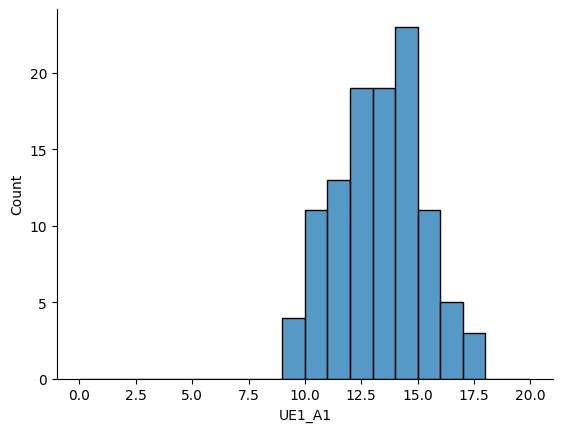

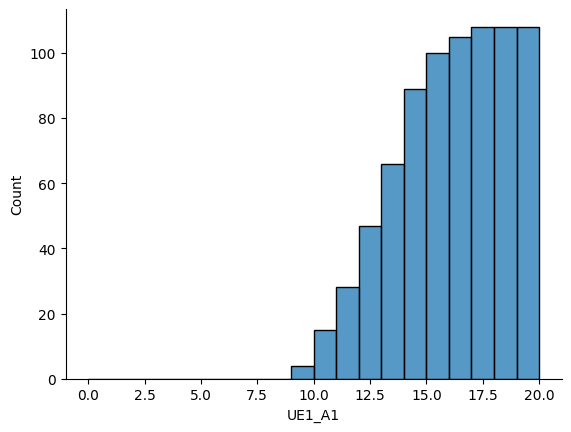

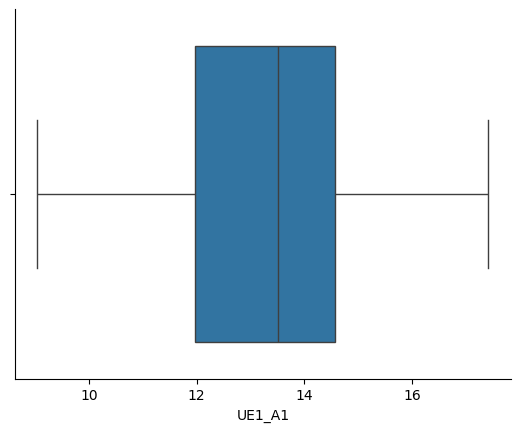

### UE2 — Année 1

Minimum: 7.34
Maximum: 17.15
Moyenne: 13.166018518518516
Variance: 4.583102691242645
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        2
(8.0, 9.0]        1
(9.0, 10.0]       6
(10.0, 11.0]     10
(11.0, 12.0]     11
(12.0, 13.0]     18
(13.0, 14.0]     17
(14.0, 15.0]     18
(15.0, 16.0]     16
(16.0, 17.0]      6
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 11.825
2e quartile : 13.34
3e quartile : 14.635
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        2
(8.0, 9.0]        1
(9.0, 10.0]       6
(10.0, 11.0]     10
(11.0, 12.0]     11
(12.0, 13.0]     18
(13.0, 14.0]     17
(14.0, 15.0]     18
(15.0, 16.0]     16
(16.0, 17.0]      6
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20

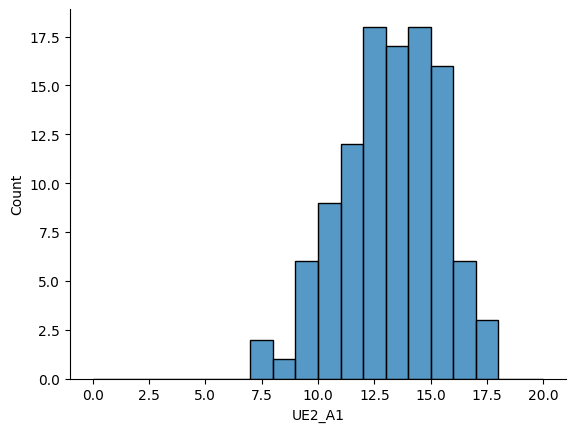

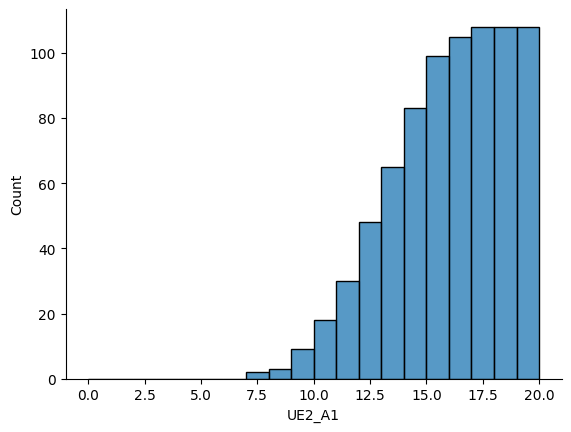

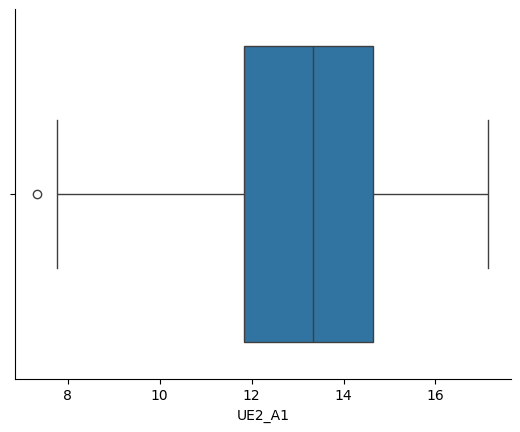

### UE3 — Année 1

Minimum: 8.02
Maximum: 16.97
Moyenne: 12.746296296296297
Variance: 4.5517039113880235
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        4
(9.0, 10.0]       9
(10.0, 11.0]      9
(11.0, 12.0]     21
(12.0, 13.0]     16
(13.0, 14.0]     16
(14.0, 15.0]     14
(15.0, 16.0]     11
(16.0, 17.0]      8
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 11.3025
2e quartile : 12.75
3e quartile : 14.46
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        4
(9.0, 10.0]       9
(10.0, 11.0]      9
(11.0, 12.0]     21
(12.0, 13.0]     16
(13.0, 14.0]     16
(14.0, 15.0]     14
(15.0, 16.0]     11
(16.0, 17.0]      8
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 2

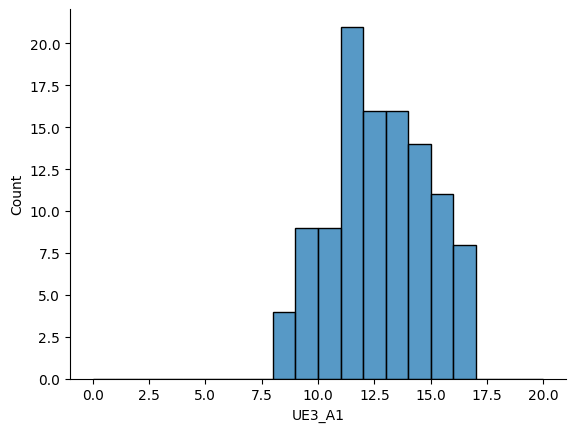

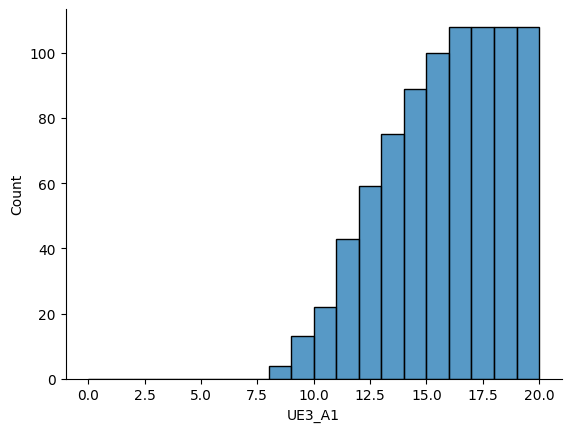

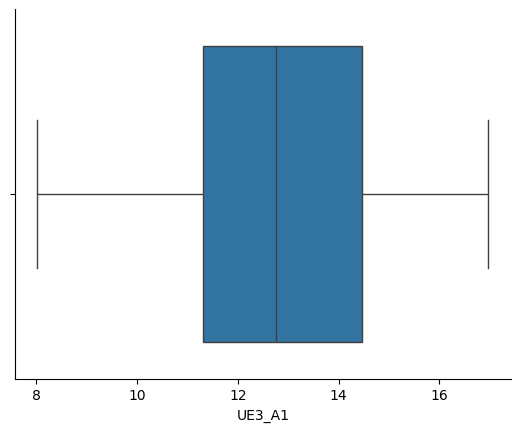

### UE4 — Année 1

Minimum: 7.64
Maximum: 16.95
Moyenne: 12.265555555555558
Variance: 2.703583800623053
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        1
(8.0, 9.0]        2
(9.0, 10.0]       6
(10.0, 11.0]     17
(11.0, 12.0]     24
(12.0, 13.0]     20
(13.0, 14.0]     25
(14.0, 15.0]      8
(15.0, 16.0]      4
(16.0, 17.0]      1
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 11.1625
2e quartile : 12.31
3e quartile : 13.5
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        1
(8.0, 9.0]        2
(9.0, 10.0]       6
(10.0, 11.0]     17
(11.0, 12.0]     24
(12.0, 13.0]     20
(13.0, 14.0]     25
(14.0, 15.0]      8
(15.0, 16.0]      4
(16.0, 17.0]      1
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20.

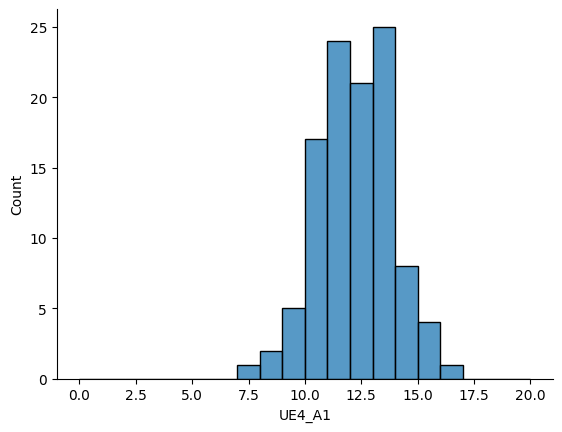

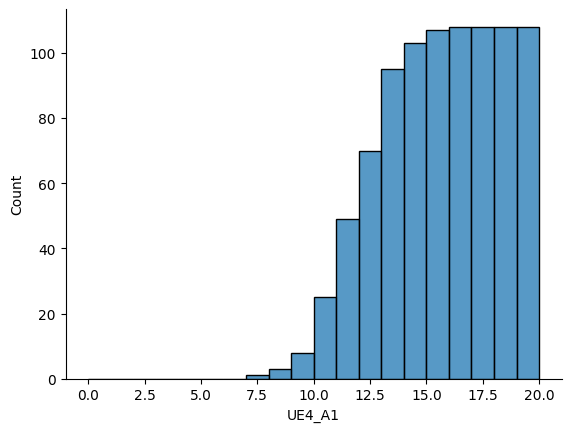

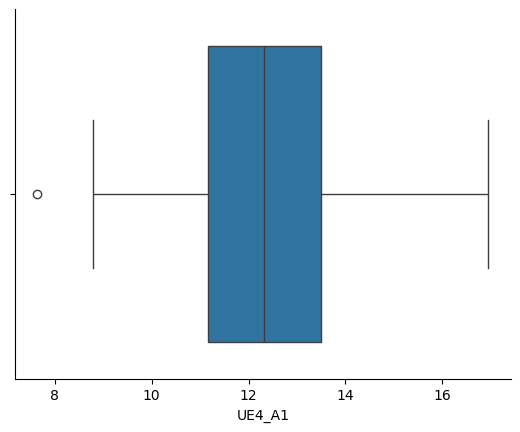

### UE5 — Année 1

Minimum: 10.66
Maximum: 16.96
Moyenne: 13.997037037037037
Variance: 1.821473381793008
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      2
(11.0, 12.0]      6
(12.0, 13.0]     13
(13.0, 14.0]     34
(14.0, 15.0]     27
(15.0, 16.0]     18
(16.0, 17.0]      8
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 13.18
2e quartile : 13.96
3e quartile : 15.0
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      2
(11.0, 12.0]      6
(12.0, 13.0]     13
(13.0, 14.0]     34
(14.0, 15.0]     27
(15.0, 16.0]     18
(16.0, 17.0]      8
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20.0

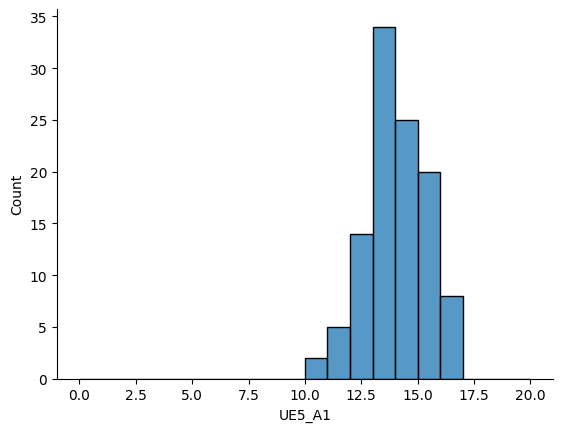

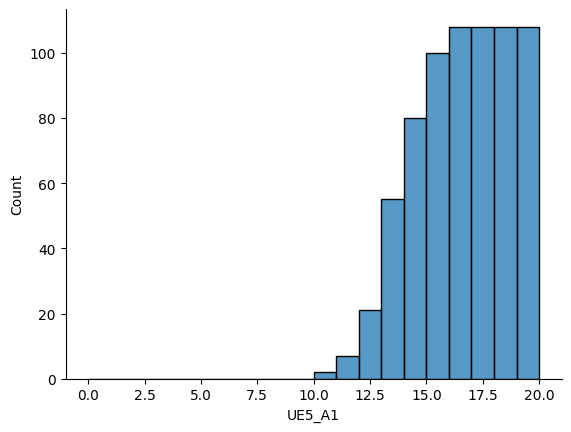

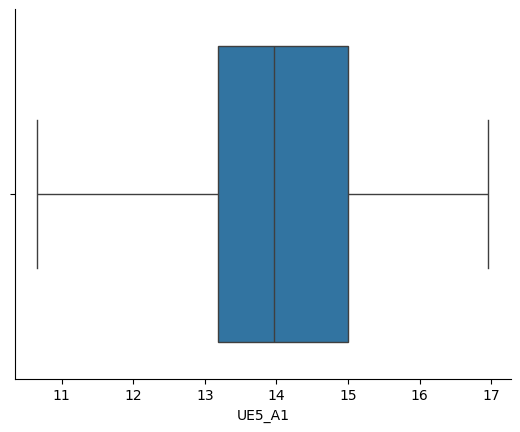

### UE6 — Année 1

Minimum: 9.78
Maximum: 16.79
Moyenne: 13.66203703703704
Variance: 2.4331509518864665
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       1
(10.0, 11.0]      4
(11.0, 12.0]     13
(12.0, 13.0]     13
(13.0, 14.0]     29
(14.0, 15.0]     26
(15.0, 16.0]     17
(16.0, 17.0]      5
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 12.64
2e quartile : 13.89
3e quartile : 14.8125
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       1
(10.0, 11.0]      4
(11.0, 12.0]     13
(12.0, 13.0]     13
(13.0, 14.0]     29
(14.0, 15.0]     26
(15.0, 16.0]     17
(16.0, 17.0]      5
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20

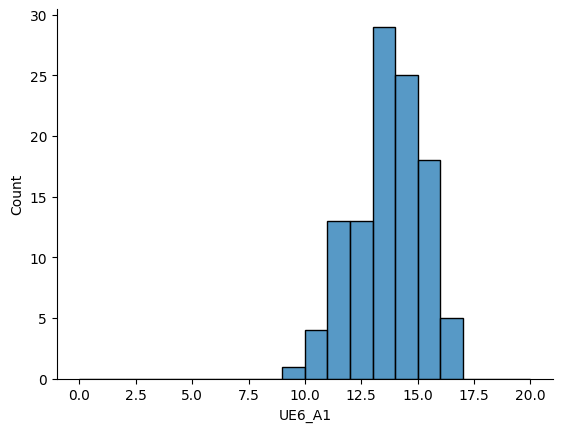

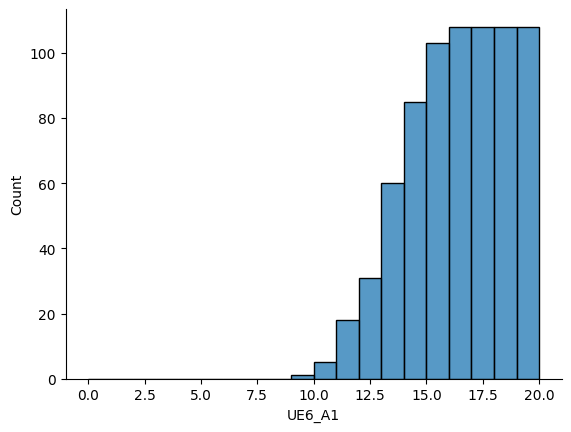

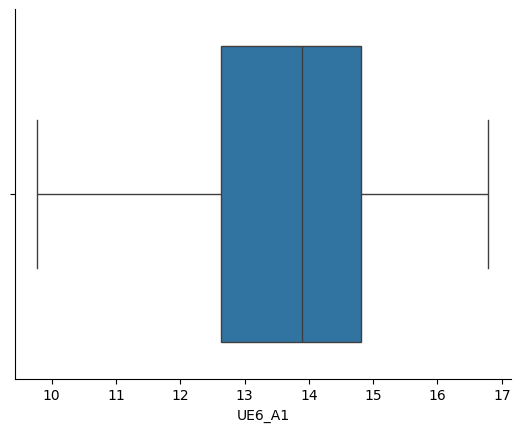

In [48]:
a1 = pd.DataFrame({
    'UE1': pd.concat([df_resultats['ue_1_1'], df_resultats['ue_2_1']]).reset_index(drop=True),
    'UE2': pd.concat([df_resultats['ue_1_2'], df_resultats['ue_2_2']]).reset_index(drop=True),
    'UE3': pd.concat([df_resultats['ue_1_3'], df_resultats['ue_2_3']]).reset_index(drop=True),
    'UE4': pd.concat([df_resultats['ue_1_4'], df_resultats['ue_2_4']]).reset_index(drop=True),
    'UE5': pd.concat([df_resultats['ue_1_5'], df_resultats['ue_2_5']]).reset_index(drop=True),
    'UE6': pd.concat([df_resultats['ue_1_6'], df_resultats['ue_2_6']]).reset_index(drop=True),
})

a2 = pd.DataFrame({
    'UE1': pd.concat([df_resultats['ue_3_1'], df_resultats['ue_4_1']]).reset_index(drop=True),
    'UE2': pd.concat([df_resultats['ue_3_2'], df_resultats['ue_4_2']]).reset_index(drop=True),
    'UE3': pd.concat([df_resultats['ue_3_3'], df_resultats['ue_4_3']]).reset_index(drop=True),
    'UE4': pd.concat([df_resultats['ue_3_4'], df_resultats['ue_4_4']]).reset_index(drop=True),
    'UE5': pd.concat([df_resultats['ue_3_5'], df_resultats['ue_4_5']]).reset_index(drop=True),
    'UE6': pd.concat([df_resultats['ue_3_6'], df_resultats['ue_4_6']]).reset_index(drop=True),
})

a3 = pd.DataFrame({
    'UE1': pd.concat([df_resultats['ue_5_1'], df_resultats['ue_6_1']]).reset_index(drop=True),
    'UE2': pd.concat([df_resultats['ue_5_2'], df_resultats['ue_6_2']]).reset_index(drop=True),
    'UE3': pd.concat([df_resultats['ue_5_6'], df_resultats['ue_6_6']]).reset_index(drop=True),
})


for col in a1.columns:
    display(Markdown(f"### {col} — Année 1"))
    analyse_quantitative_continue(a1[col].dropna().rename(f'{col}_A1'), bins=np.linspace(0, 20, 21))

#### Année 1


UE5 est la mieux réussie de l'année avec 13,99 suivie de UE6 à 13,66 et UE1 à 13,31.UE5 est la mieux réussie de l'année avec 13,99 suivie de UE6 à 13,66 et UE1 à 13,31. UE4 est la moins bien réussie à 12,27 malgré une variance faible à 2,70 tout le monde est homogènement bas sur cette UE. UE2 et UE3 affichent les variances les plus élevées à 4,58 et 4,55 les niveaux sont très éparpillés sur ces UE certains s'en sortent bien d'autres beaucoup moins. UE5 a la variance la plus faible de l'année à 1,82 c'est l'UE où tout le monde performe de façon homogène et au dessus de 13. L'écart entre la meilleure et la moins bonne UE est de 1,73 pts entre UE5 et UE4.

---

### UE1 — Année 2

Minimum: 10.31
Maximum: 17.11
Moyenne: 13.983333333333334
Variance: 2.700122463768116
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      3
(11.0, 12.0]     11
(12.0, 13.0]     13
(13.0, 14.0]     18
(14.0, 15.0]     21
(15.0, 16.0]     16
(16.0, 17.0]      9
(17.0, 18.0]      2
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 12.76
2e quartile : 14.24
3e quartile : 15.13
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      3
(11.0, 12.0]     11
(12.0, 13.0]     13
(13.0, 14.0]     18
(14.0, 15.0]     21
(15.0, 16.0]     16
(16.0, 17.0]      9
(17.0, 18.0]      2
(18.0, 19.0]      0
(19.0, 20.

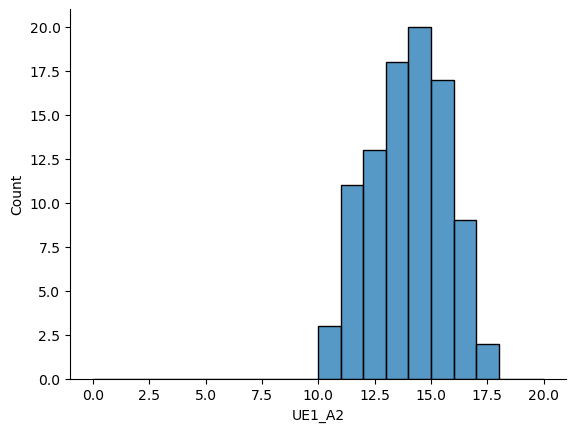

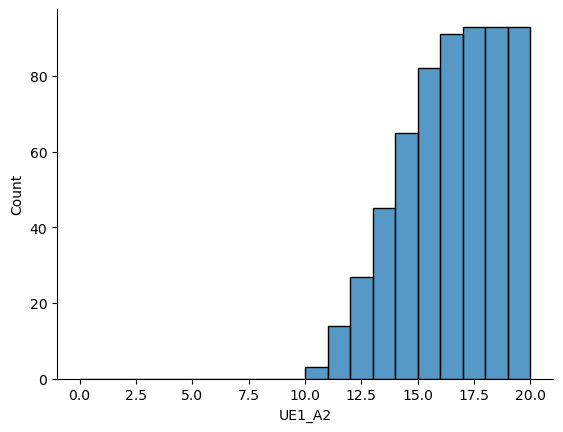

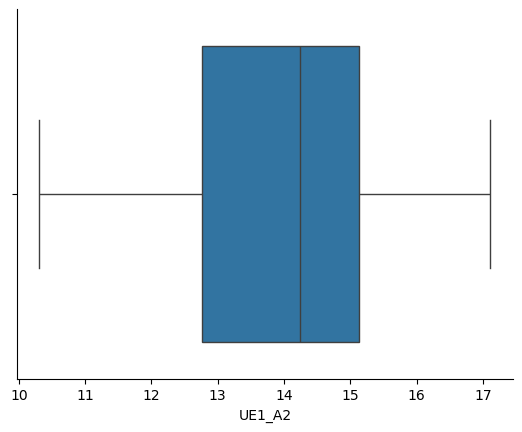

### UE2 — Année 2

Minimum: 9.67
Maximum: 17.66
Moyenne: 13.898322580645162
Variance: 3.0584668948106604
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       1
(10.0, 11.0]      7
(11.0, 12.0]      7
(12.0, 13.0]     12
(13.0, 14.0]     18
(14.0, 15.0]     26
(15.0, 16.0]     10
(16.0, 17.0]      8
(17.0, 18.0]      4
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 12.88
2e quartile : 14.05
3e quartile : 14.954
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       1
(10.0, 11.0]      7
(11.0, 12.0]      7
(12.0, 13.0]     12
(13.0, 14.0]     18
(14.0, 15.0]     26
(15.0, 16.0]     10
(16.0, 17.0]      8
(17.0, 18.0]      4
(18.0, 19.0]      0
(19.0, 20

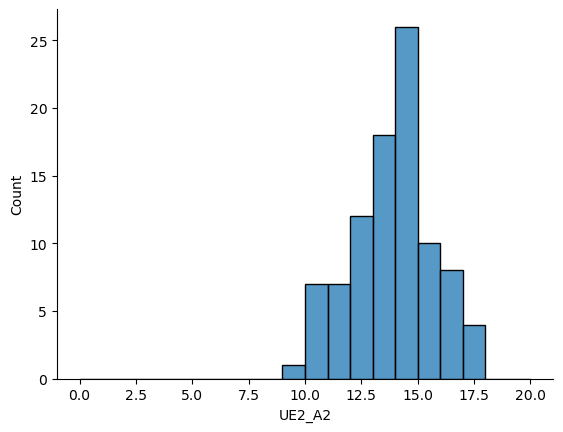

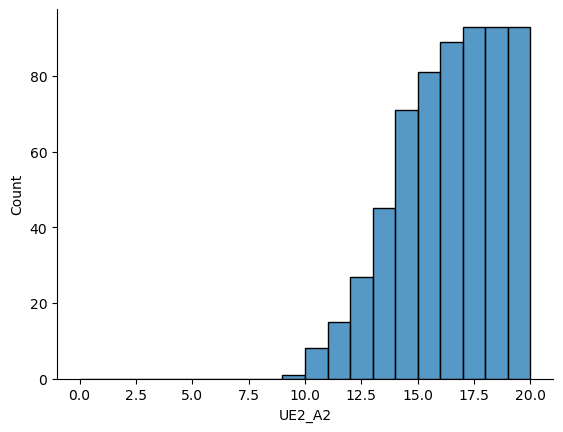

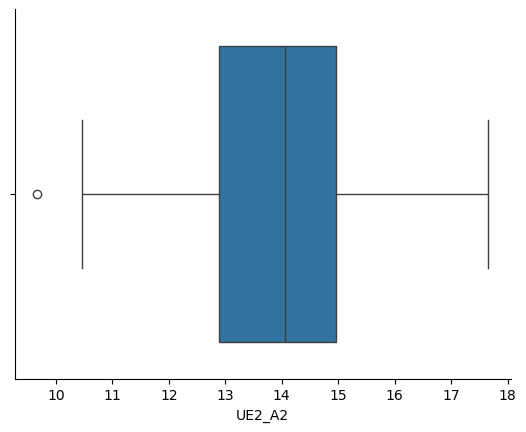

### UE3 — Année 2

Minimum: 7.69
Maximum: 17.29
Moyenne: 13.323655913978493
Variance: 4.16673648901356
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        1
(8.0, 9.0]        1
(9.0, 10.0]       4
(10.0, 11.0]      6
(11.0, 12.0]     11
(12.0, 13.0]     15
(13.0, 14.0]     21
(14.0, 15.0]     14
(15.0, 16.0]     10
(16.0, 17.0]      7
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 12.08
2e quartile : 13.54
3e quartile : 14.61
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        1
(8.0, 9.0]        1
(9.0, 10.0]       4
(10.0, 11.0]      6
(11.0, 12.0]     11
(12.0, 13.0]     15
(13.0, 14.0]     21
(14.0, 15.0]     14
(15.0, 16.0]     10
(16.0, 17.0]      7
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20.0]

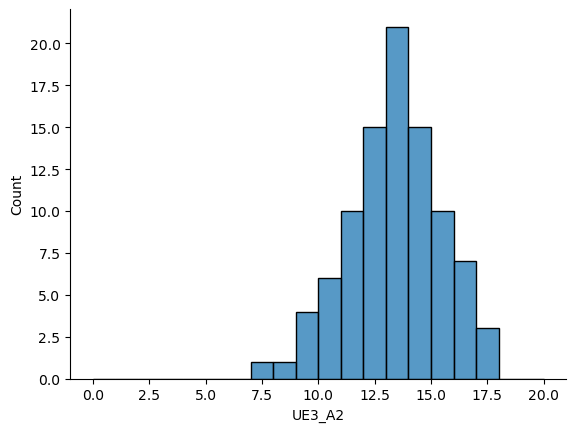

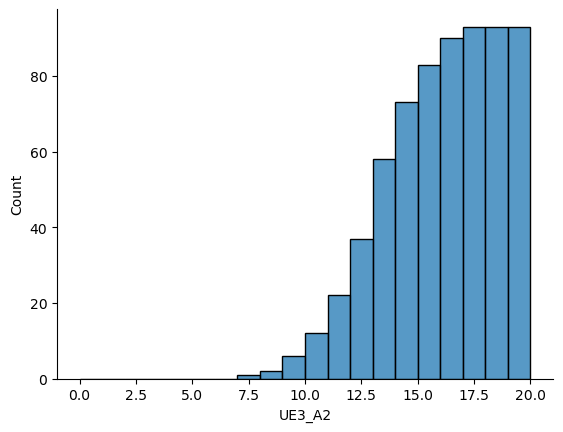

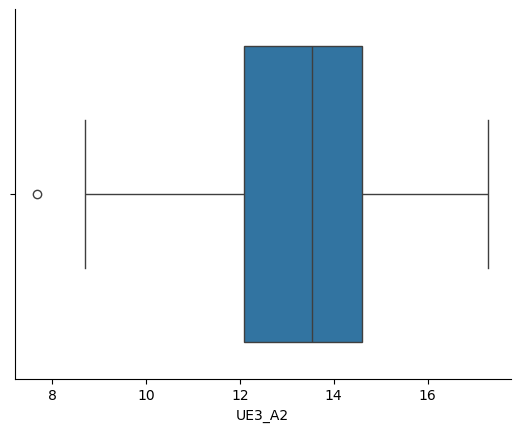

### UE4 — Année 2

Minimum: 10.66
Maximum: 16.74
Moyenne: 13.998387096774193
Variance: 1.9524049789621318
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      1
(11.0, 12.0]      9
(12.0, 13.0]     14
(13.0, 14.0]     19
(14.0, 15.0]     28
(15.0, 16.0]     16
(16.0, 17.0]      6
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 12.93
2e quartile : 14.11
3e quartile : 14.98
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      1
(11.0, 12.0]      9
(12.0, 13.0]     14
(13.0, 14.0]     19
(14.0, 15.0]     28
(15.0, 16.0]     16
(16.0, 17.0]      6
(17.0, 18.0]      0
(18.0, 19.0]      0
(19.0, 20

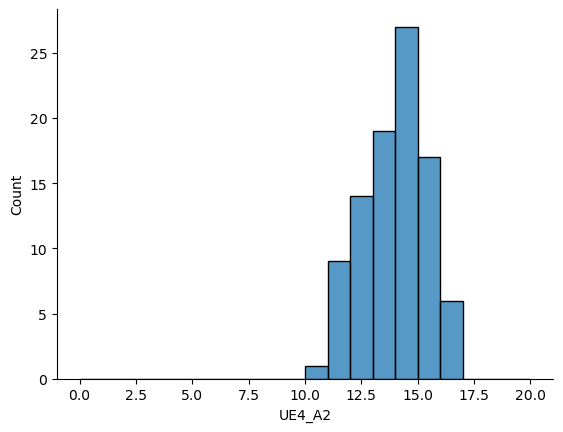

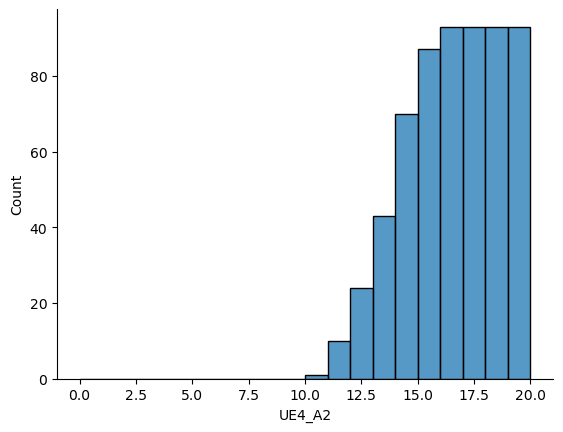

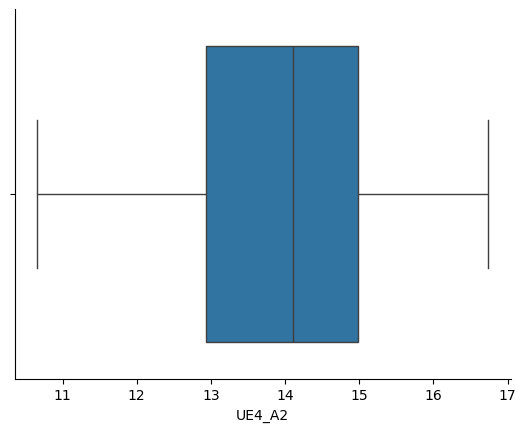

### UE5 — Année 2

Minimum: 10.88
Maximum: 17.33
Moyenne: 14.645913978494626
Variance: 2.051024427302477
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      1
(11.0, 12.0]      2
(12.0, 13.0]     12
(13.0, 14.0]     16
(14.0, 15.0]     19
(15.0, 16.0]     28
(16.0, 17.0]     12
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 13.78
2e quartile : 14.82
3e quartile : 15.72
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      1
(11.0, 12.0]      2
(12.0, 13.0]     12
(13.0, 14.0]     16
(14.0, 15.0]     19
(15.0, 16.0]     28
(16.0, 17.0]     12
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20.

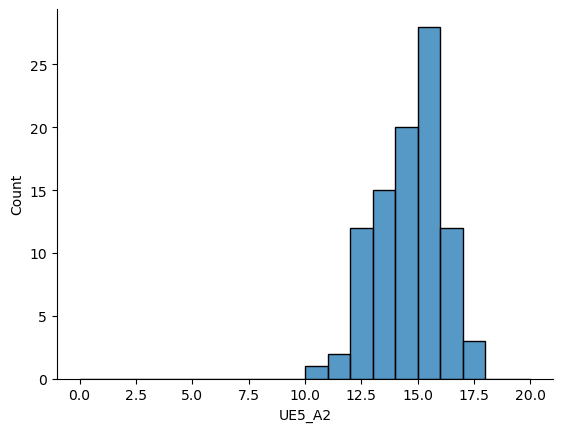

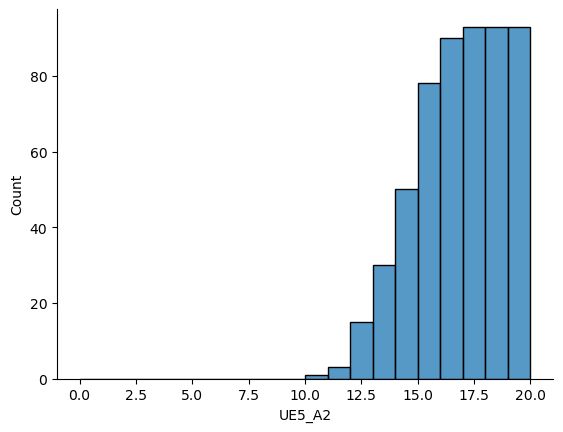

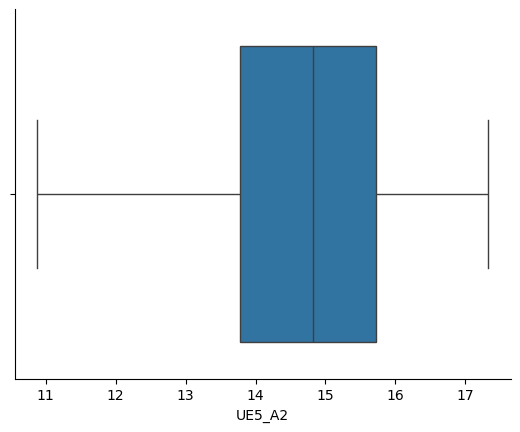

### UE6 — Année 2

Minimum: 10.04
Maximum: 17.23
Moyenne: 14.126989247311828
Variance: 2.567597358578775
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      3
(11.0, 12.0]      9
(12.0, 13.0]     13
(13.0, 14.0]     11
(14.0, 15.0]     27
(15.0, 16.0]     21
(16.0, 17.0]      8
(17.0, 18.0]      1
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 12.85
2e quartile : 14.41
3e quartile : 15.31
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      3
(11.0, 12.0]      9
(12.0, 13.0]     13
(13.0, 14.0]     11
(14.0, 15.0]     27
(15.0, 16.0]     21
(16.0, 17.0]      8
(17.0, 18.0]      1
(18.0, 19.0]      0
(19.0, 20.

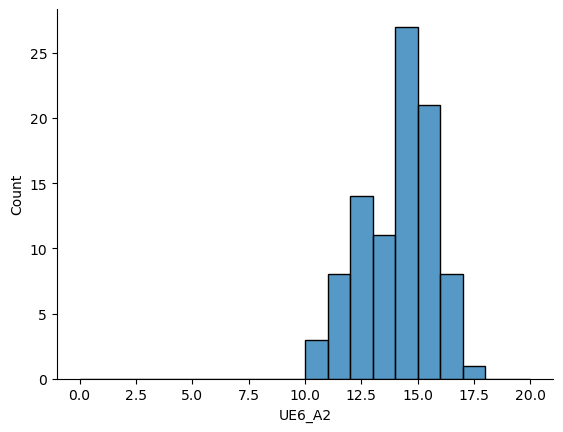

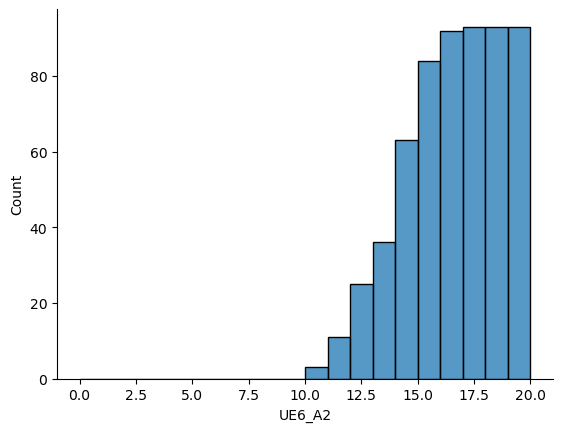

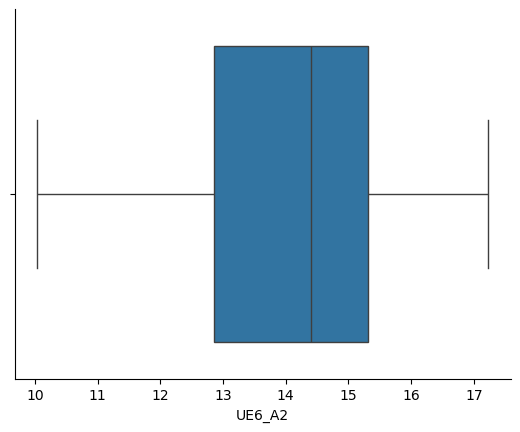

In [12]:
for col in a2.columns:
    display(Markdown(f"### {col} — Année 2"))
    analyse_quantitative_continue(a2[col].dropna().rename(f'{col}_A2'), bins=np.linspace(0, 20, 21))

#### Année 2

UE5 est la mieux réussie de l'année avec 14,65 suivie de UE4 à 14,00 et UE1 à 13,98. UE3 est la moins bien réussie à 13,32 avec la variance la plus élevée de l'année à 4,17 les niveaux sont très éparpillés certains s'en sortent bien d'autres beaucoup moins. UE4 et UE5 affichent les variances les plus faibles à 1,95 et 2,05. L'écart entre la meilleure et la moins bonne UE est de 1,32 pts entre UE5 et UE3 plus resserré qu'en année 1.

---

### UE1 — Année 3

Minimum: 10.29
Maximum: 17.36
Moyenne: 14.530235294117647
Variance: 2.497254705882353
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      1
(11.0, 12.0]      4
(12.0, 13.0]     13
(13.0, 14.0]     13
(14.0, 15.0]     14
(15.0, 16.0]     27
(16.0, 17.0]     10
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 13.24
2e quartile : 14.8
3e quartile : 15.72
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      1
(11.0, 12.0]      4
(12.0, 13.0]     13
(13.0, 14.0]     13
(14.0, 15.0]     14
(15.0, 16.0]     27
(16.0, 17.0]     10
(17.0, 18.0]      3
(18.0, 19.0]      0
(19.0, 20.0

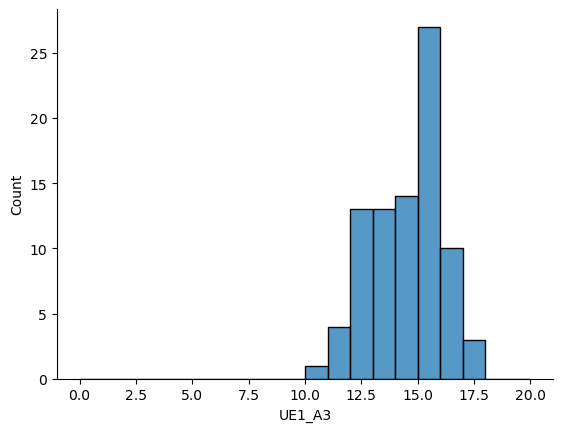

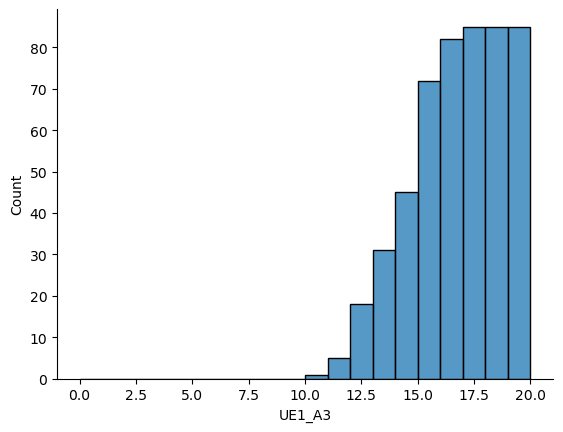

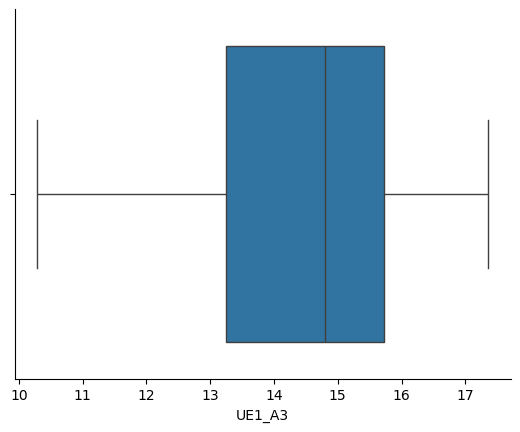

### UE2 — Année 3

Minimum: 10.9
Maximum: 17.36
Moyenne: 14.537647058823527
Variance: 2.5199467787114838
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      1
(11.0, 12.0]      5
(12.0, 13.0]     11
(13.0, 14.0]     15
(14.0, 15.0]     13
(15.0, 16.0]     28
(16.0, 17.0]      8
(17.0, 18.0]      4
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 13.29
2e quartile : 14.83
3e quartile : 15.74
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       0
(10.0, 11.0]      1
(11.0, 12.0]      5
(12.0, 13.0]     11
(13.0, 14.0]     15
(14.0, 15.0]     13
(15.0, 16.0]     28
(16.0, 17.0]      8
(17.0, 18.0]      4
(18.0, 19.0]      0
(19.0, 20.

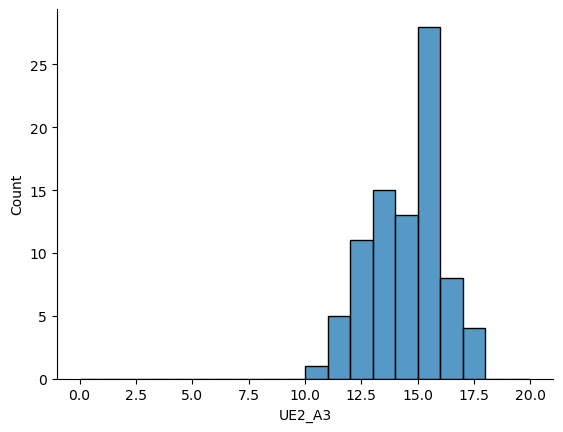

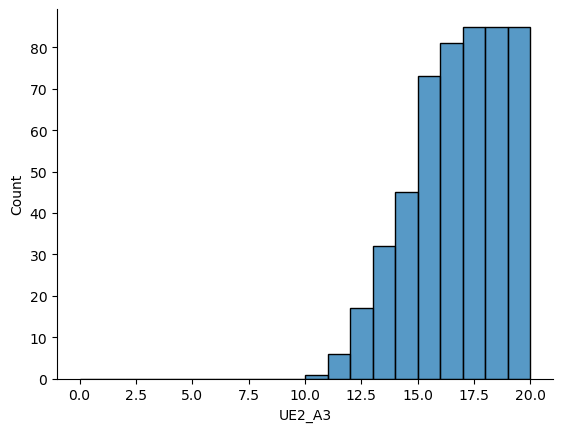

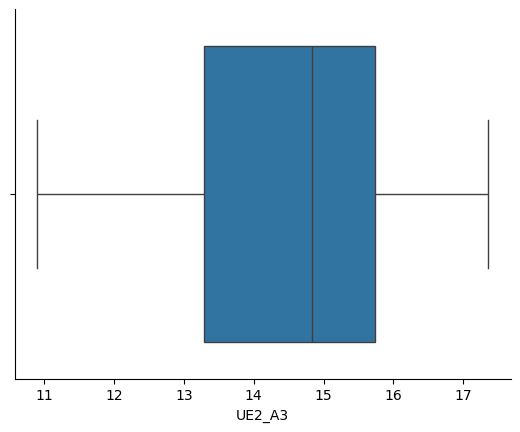

### UE3 — Année 3

Minimum: 9.88
Maximum: 17.13
Moyenne: 14.473294117647056
Variance: 1.9062080672268895
Tabulation des fréquences:
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       1
(10.0, 11.0]      0
(11.0, 12.0]      2
(12.0, 13.0]     10
(13.0, 14.0]     14
(14.0, 15.0]     23
(15.0, 16.0]     22
(16.0, 17.0]     12
(17.0, 18.0]      1
(18.0, 19.0]      0
(19.0, 20.0]      0
Name: count, dtype: int64
Quartiles:
1er quartile: 13.57
2e quartile : 14.45
3e quartile : 15.49
(-0.001, 1.0]     0
(1.0, 2.0]        0
(2.0, 3.0]        0
(3.0, 4.0]        0
(4.0, 5.0]        0
(5.0, 6.0]        0
(6.0, 7.0]        0
(7.0, 8.0]        0
(8.0, 9.0]        0
(9.0, 10.0]       1
(10.0, 11.0]      0
(11.0, 12.0]      2
(12.0, 13.0]     10
(13.0, 14.0]     14
(14.0, 15.0]     23
(15.0, 16.0]     22
(16.0, 17.0]     12
(17.0, 18.0]      1
(18.0, 19.0]      0
(19.0, 20.

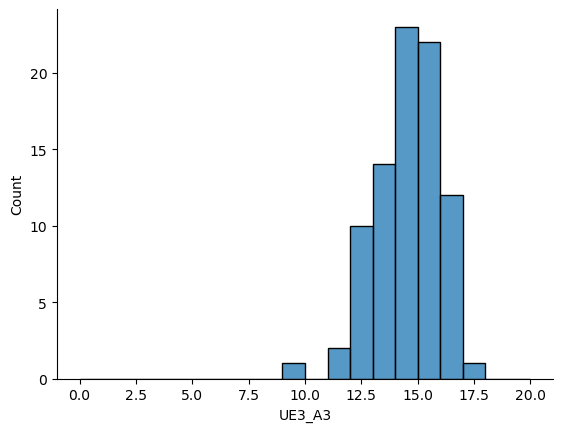

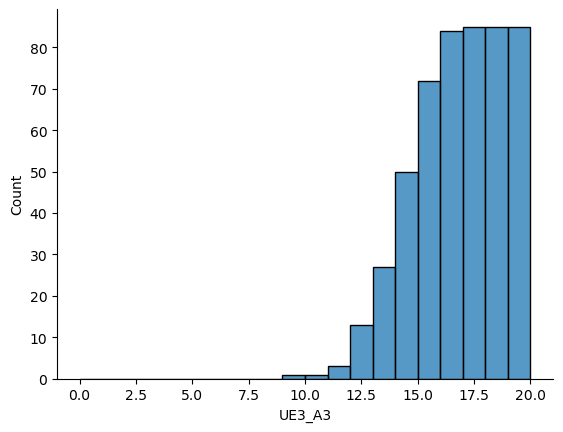

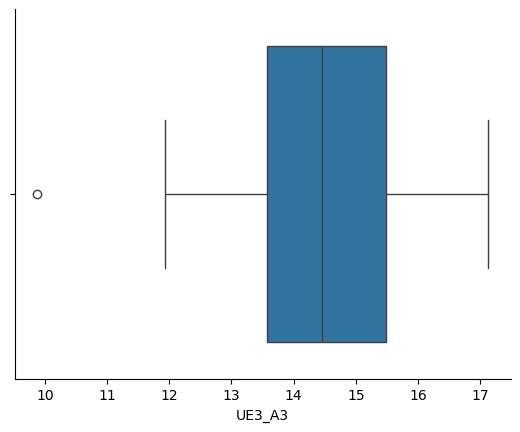

In [13]:
for col in a3.columns:
    display(Markdown(f"### {col} — Année 3"))
    analyse_quantitative_continue(a3[col].dropna().rename(f'{col}_A3'), bins=np.linspace(0, 20, 21))

#### Année 3

En année 3 les trois UE sont très proches, toutes entre 14,47 et 14,54. UE1 et UE2 sont légèrement devant à 14,53 et 14,54 mais l'écart est tellement faible qu'on peut pas vraiment dire qu'une UE se démarque vraiment.

---
# Évolution des taux de réussite annuelle

Dans cette section nous allons étudier les résultats  des étudiants apres chaque année de BUT avec les variables res_but_1, res_but_2 
et res_but_3. Pour ce faire nous allons réaliser les étapes suivantes :
- Effectif total et répartition des modalités
- Mode et médiane ordinale
- Tableau de distribution des effectifs et fréquences
- Diagramme en barres

### Répartition des absences et des retards (`nature`)

Nous allons à présent calculer le nombre d\'abcences par élèves pour toute la formation (les 3 ans)

Commencons par créer nos variables, nb_ret et nb_abs :

In [14]:
def calculer_nb_absences_demi_journees(code_etu, df_abs, type_absence='absence'):
    """
    Calcule le nombre de demi-journées d'absence pour un élève donné.
    Déduplique les absences d'une même matinée ou d'un même après-midi.
    """
    df_etu = df_abs[(df_abs['code_etu'] == code_etu) & (df_abs['nature'].str.lower() == type_absence)].copy()
    
    if df_etu.empty:
        return 0
    
    df_etu['datetime'] = pd.to_datetime(df_etu['date'])
    
    df_etu['jour'] = df_etu['datetime'].dt.date
    df_etu['heure'] = df_etu['datetime'].dt.hour
    
    df_etu['creneau'] = df_etu['heure'].apply(lambda x: 'matin' if x < 13 else 'apres_midi')
    
    demi_journees_uniques = df_etu.drop_duplicates(subset=['jour', 'creneau'])
    
    return len(demi_journees_uniques)
  
# Calcul du nombre total de demi-journées d'absence pour chaque élève

for code_etu in df_resultats['code_etu']:
    nb_absences_1 = calculer_nb_absences_demi_journees(code_etu, df_abs_1, 'absence')
    nb_absences_2 = calculer_nb_absences_demi_journees(code_etu, df_abs_2, 'absence')
    nb_absences_3 = calculer_nb_absences_demi_journees(code_etu, df_abs_3, 'absence')
    
    df_resultats.loc[df_resultats['code_etu'] == code_etu, 'nb_abs'] = nb_absences_1 + nb_absences_2 + nb_absences_3

print("Moyenne du nombre de demi-journées d'absence :", df_resultats['nb_abs'].mean())
print("Variance du nombre de demi-journées d'absence :", df_resultats['nb_abs'].var())
print("Écart-type du nombre de demi-journées d'absence :", df_resultats['nb_abs'].std())

for code_etu in df_resultats['code_etu']:
    nb_retards_1 = calculer_nb_absences_demi_journees(code_etu, df_abs_1, 'retard')
    nb_retards_2 = calculer_nb_absences_demi_journees(code_etu, df_abs_2, 'retard')
    nb_retards_3 = calculer_nb_absences_demi_journees(code_etu, df_abs_3, 'retard')

    df_resultats.loc[df_resultats['code_etu'] == code_etu, 'nb_ret'] = nb_retards_1 + nb_retards_2 + nb_retards_3


Moyenne du nombre de demi-journées d'absence : 12.859649122807017
Variance du nombre de demi-journées d'absence : 267.62280701754395
Écart-type du nombre de demi-journées d'absence : 16.359181123074098


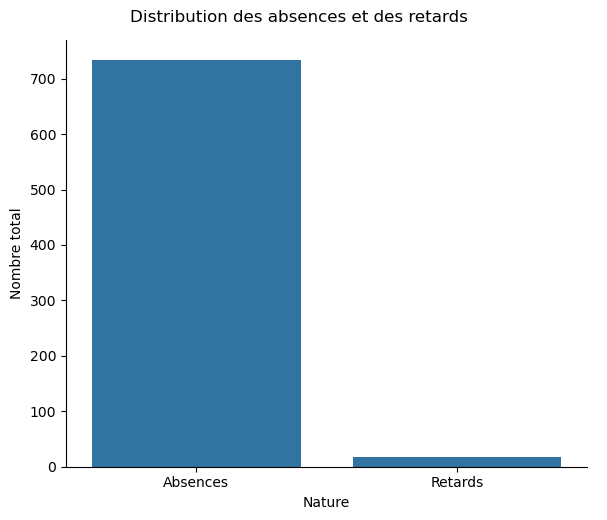

In [15]:
# Remettons en forme avec la nature : 
df_melted = pd.DataFrame({
    'nature': ['Absences', 'Retards'],
    'nombre_total': [
        df_resultats['nb_abs'].sum(),
        df_resultats['nb_ret'].sum()
    ]
})

# Tracé de la distribution de nb_retards et nb_absences

g = sns.catplot(data=df_melted, x='nature', y='nombre_total', kind='bar', height=5, aspect=1.2)
g.set_axis_labels('Nature', 'Nombre total')
g.fig.suptitle("Distribution des absences et des retards", y=1.03)
g.set_xticklabels(rotation=0)

Maintenant nous voyons clairement la différence, il y a clairement plus d'absence que de retard.

### Répartition des absences et des retards (`type`)

In [16]:
# Passons à présent à la variable type

df_abs_total.type.value_counts()

type
TD                      559
TP                      340
CM                       75
EVALUATION               31
PROJET                    2
RÉUNION STAGE             2
CM+TD                     2
PRÉSENTATION PEPITES      2
SAE                       2
PRESENTATION STAGE        1
CGI                       1
Name: count, dtype: int64

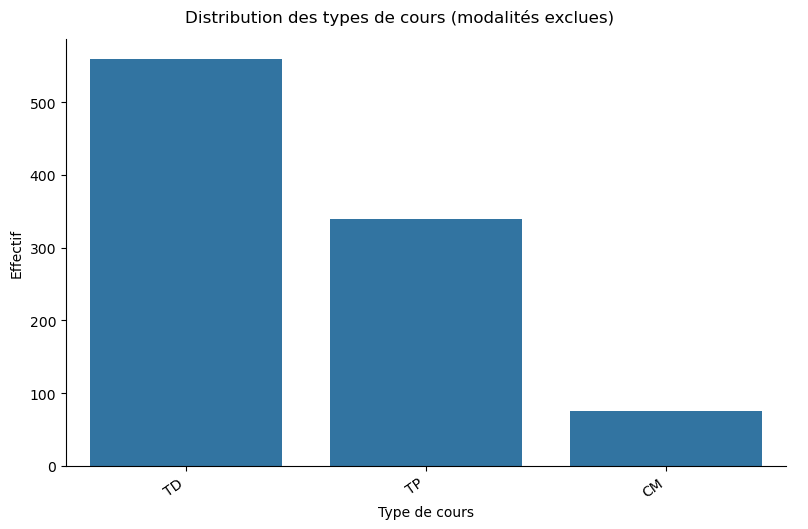

In [17]:
modalites_a_exclure = [
    'EVALUATION',
    'PROJET',
    'RÉUNION STAGE',
    'CM+TD',
    'PRÉSENTATION PEPITES',
    'SAE',
    'PRESENTATION STAGE',
    'CGI'
]

series_type = df_abs_total['type'].astype(str).str.strip()

df_type_plot = (
    series_type[~series_type.isin(modalites_a_exclure)]
    .value_counts()
    .reset_index()
)
df_type_plot.columns = ['type', 'effectif']

g = sns.catplot(
    data=df_type_plot,
    x='type',
    y='effectif',
    kind='bar',
    height=5,
    aspect=1.6
)
g.set_axis_labels('Type de cours', 'Effectif')
g.fig.suptitle('Distribution des types de cours (modalités exclues)', y=1.03)
g.set_xticklabels(rotation=35, horizontalalignment='right')

En **conclusion**, les travaux dirigés concentrent plus de la moitié des absences recensées. Cela s’explique avant tout par leur poids horaire : dans la maquette pédagogique du BUT Informatique, les TD constituent le format de cours le plus fréquent. Il est donc cohérent qu’ils cumulent le plus grand nombre de manquements en valeur absolue.

À l’inverse, les cours magistraux ne représentent que 7,7 % des absences. Ce faible taux peut s’expliquer par leur format, davantage basé sur la transmission passive de connaissances et moins exigeant en termes de participation active. Il faut également noter que les CM sont moins nombreux dans l’emploi du temps.

Pour approfondir cette analyse, il conviendrait de rapporter ces chiffres au nombre total de séances de chaque type, afin d’obtenir un taux d’absence par rapport au type. Cela permettrait de déterminer si les étudiants sont proportionnellement plus absents en TD, en TP ou en CM.

### Analyse de la durée et des extrapolations des retards (`duree_retard`)

In [18]:
# Toutes les modalités :
df_abs_total.duree_retard.value_counts()

duree_retard
30.0    4
15.0    4
25.0    2
60.0    2
40.0    1
20.0    1
55.0    1
90.0    1
50.0    1
10.0    1
Name: count, dtype: int64

Calculons la distribution des fréquences à l'aide du paramètre `normalize=True`

In [19]:
df_abs_total.duree_retard.value_counts(normalize=True)

duree_retard
30.0    0.222222
15.0    0.222222
25.0    0.111111
60.0    0.111111
40.0    0.055556
20.0    0.055556
55.0    0.055556
90.0    0.055556
50.0    0.055556
10.0    0.055556
Name: proportion, dtype: float64

Calculons les fréquences cumulés : 

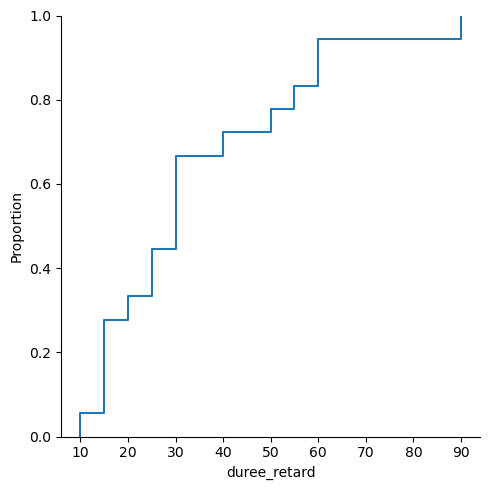

In [20]:
sns.displot(x='duree_retard', data = df_abs_total, kind = 'ecdf')

Calculons la moyenne, variance et écart-type de la variable

In [21]:
print(f"Moyenne : {df_abs_total['duree_retard'].mean():.2f}")
print(f"Écart-type : {df_abs_total['duree_retard'].std():.2f}")

Moyenne : 34.17
Écart-type : 21.23


Créeons à présent la boîte à moustache pour avoir les valeurs exagérentes qui sort du lot

In [22]:
print("Q1 = ",df_abs_total.duree_retard.quantile(q=0.25))
print("Q2 = M = ",df_abs_total.duree_retard.quantile(q=0.5))
print("Q3 = ",df_abs_total.duree_retard.quantile(q=0.75))
print(f"Interquartile : {df_abs_total.duree_retard.quantile(q=0.75) - df_abs_total.duree_retard.quantile(q=0.25)}")

Q1 =  16.25
Q2 = M =  30.0
Q3 =  47.5
Interquartile : 31.25


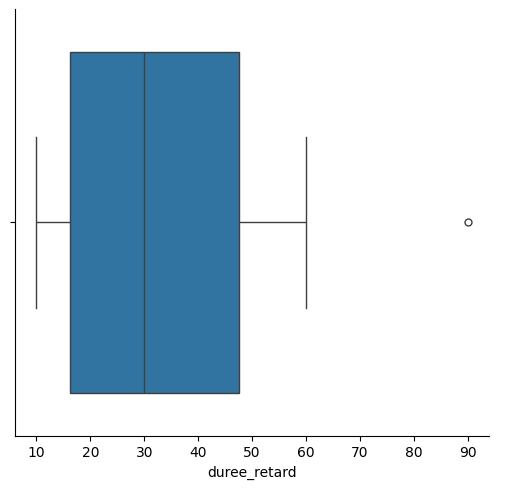

In [ ]:
sns.catplot(x='duree_retard', data=df_abs_total, whis=1, kind='box')

Le facteur 1.5 a été établi pour des grands échantillons avec une distribution proche de la normale. Avec seulement n = 18 valeurs, cet écart-type implicite est trop généreux et la moustache s'étire artificiellement.

**Conclusion**: 

Parmi ces retards, la moitié dure moins de 30 minutes, et en moyenne ils tournent autour de 34 minutes. Ça montre que la plupart des retards restent plutôt raisonnables. Les durées les plus courantes sont 15 et 30 minutes (4 fois chacune), ce qui donne l'impression que les gens arrivent souvent en milieu de créneau.


Si on utilise une boîte à moustaches avec whis=1.0 (ce qui se justifie vu qu'on a seulement 18 valeurs), la limite haute est fixée à 78,75 minutes. Du coup, le retard de 90 minutes ressort comme le seul cas vraiment extrême : c'est presque la moitié d'un TP de 3 heures, ce qui ressemble plus à une demi-absence qu'à un simple retard.

Mode: Nathalie VIEILLARD
Tableau de distribution (effectifs):
enseignant
Nathalie VIEILLARD       262
Yann WALKOWIAK           137
Olivier ROULIN           114
Bruno ERNET               89
Lahcen OUBAHSSI           49
Ludovic HAMON             49
Pierre LAFORCADE          47
Sebastien GEORGE          39
Adeline FOUCAULT          27
Charles DECELLIERES       22
Mohamed Nail HEFIED       18
Pierre-Jean PETITPREZ     17
Berenice LEMOINE          16
Mohamed KOUMTANI          16
Estelle YVEN              15
Remi VENANT               14
Nadege RIBOT              12
Guy-Junior PERRIN          9
Mohamed EZ-ZAOUIA          9
Alain CORBIERE             7
Iza MARFISI                6
Emmanuel BROCHARD          6
Hélène CROZET              5
Sebastian SIMON            4
Alain RIBAULT              4
Noémie GIRAUD              4
Thomas TARDIF              4
Thomas PAUCHARD            4
Tawfiq CADI TAZI           3
Marouane HIMDI             3
Jeremie GROULET            2
Stephane AMAR              2

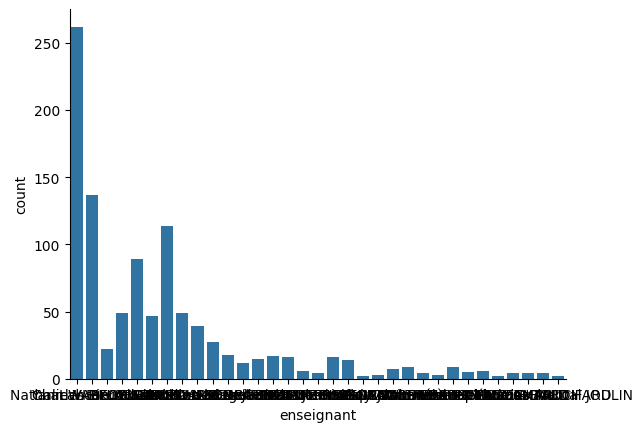

In [ ]:
df_abs_total = pd.concat([df_abs_1, df_abs_2, df_abs_3], ignore_index=True)

analyse_qualitative_nominale(df_abs_total['enseignant'])

Cette concentration montre un nombre élevé d'heures de cours assurées par ces enseignants, combiné à leur rigueur constante lors de la prise des présences.